# 환경

In [1]:
import os
import sys

PROJECT_ROOT = os.path.expanduser("~/jowithu/Semantic/IEC")
os.chdir(PROJECT_ROOT)

for p in [
    PROJECT_ROOT,
    os.path.join(PROJECT_ROOT, "mainldm"),      # ← 추가
    os.path.join(PROJECT_ROOT, "mainddpm"),
    os.path.join(PROJECT_ROOT, "src", "taming-transformers"),
]:
    if p not in sys.path:
        sys.path.insert(0, p)
        
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

import torch
print("CWD:", os.getcwd())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())  # 1 나와야 정상
print("GPU:", torch.cuda.get_device_name(0))

CWD: /home/user/jowithu/Semantic/IEC
PyTorch: 2.0.1+cu118
CUDA available: True
Device count: 1
GPU: NVIDIA GeForce RTX 4090


# S-IEC 컴포넌트 sanity check

In [2]:
from siec_core.syndrome import compute_syndrome
from siec_core.correction import compute_gamma, apply_consensus_correction
from siec_core.threshold import calibrate_tau_from_scores

import torch
import numpy as np

# Toy와 구현 일치 확인
torch.manual_seed(0)
x0_a = torch.randn(4, 3, 8, 8)
x0_b = torch.randn(4, 3, 8, 8)

syn, score = compute_syndrome(x0_a, x0_b)
d = 3 * 8 * 8
expected = ((x0_a[0] - x0_b[0]) ** 2).sum().item() / d
print(f"Score[0]: {score[0].item():.6f}  (expected {expected:.6f})")
assert abs(expected - score[0].item()) < 1e-5

gamma = compute_gamma(0.8, 0.2, c=1.0)
expected_gamma = 0.2 / 1.2
print(f"Gamma: {gamma:.6f}  (expected {expected_gamma:.6f})")
assert abs(gamma - expected_gamma) < 1e-5

print("\n✓ siec_core sanity OK")

Score[0]: 2.019359  (expected 2.019359)
Gamma: 0.166667  (expected 0.166667)

✓ siec_core sanity OK


# args 구성

In [3]:
import argparse
import yaml

def dict2namespace(d):
    ns = argparse.Namespace()
    for k, v in d.items():
        setattr(ns, k, dict2namespace(v) if isinstance(v, dict) else v)
    return ns

args_dict = {
    'config': './mainddpm/configs/cifar10.yml',
    'seed': 1234 + 9,
    'device': 'cuda',
    'exp': 'deepcache',
    'image_folder': './error_dec/cifar/image_siec_pilot_nb',
    'fid': True,
    'interpolation': False, 'resume_training': False, 'ni': True,
    'use_pretrained': True,
    'sample_type': 'generalized', 'skip_type': 'quad',
    'timesteps': 100, 'eta': 0.0,
    'sequence': False, 'select_step': None, 'select_depth': None,
    'cache': True, 'replicate_interval': 10,
    'non_uniform': False, 'pow': None, 'center': None,
    'branch': 2,
    'num_samples': 500,   # pilot은 500
    'sample_batch': 100,
    'sm_abit': 8, 'quant_act': True,
    'weight_bit': 8, 'act_bit': 8, 'quant_mode': 'qdiff',
    'lr_w': 1e-4, 'lr_a': 1e-4, 'lr_z': 1e-4,
    'split': True, 'ptq': True, 'dps_steps': False, 'recon': False,
    # S-IEC
    'use_siec': True,
    'c_siec': 1.0,
    'tau_path': './calibration/tau_schedule_p80.pt',
    'tau_percentile': 80.0,
    'siec_always_correct': False,
    'siec_collect_scores': False,
    'siec_scores_out': './calibration/pilot_scores_nb.pt',
    'siec_max_rounds': 1,
}
args = dict2namespace(args_dict)

with open(args.config, 'r') as f:
    config = dict2namespace(yaml.safe_load(f))
config.select_step = args.select_step
config.select_depth = args.select_depth

args.mode = 'dps_opt' if args.dps_steps else 'uni'

os.makedirs(args.image_folder, exist_ok=True)
os.makedirs('./calibration', exist_ok=True)

print(f"args ready. num_samples={args.num_samples}, batch={args.sample_batch}")

args ready. num_samples=500, batch=100


# Model 로드 + Quantization

In [4]:
import logging
from accelerate import Accelerator

# ★ CLI 스크립트와 동일한 import 경로 사용
from quant.utils import seed_everything
from quant.quant_model import QModel
from quant.set_quantize_params import set_act_quantize_params, set_weight_quantize_params
from ddpm.runners.deepcache import Diffusion   # ← mainddpm. prefix 제거

import torch

logging.basicConfig(level=logging.INFO)

accelerator = Accelerator()
args.accelerator = accelerator
seed_everything(args.seed)

# Calibration 로드
cal_path = f"./calibration/cifar{args.timesteps}_cache{args.replicate_interval}_{args.mode}.pth"
interval_seq, all_cali_data, all_t, all_cali_t, all_cache = torch.load(cal_path)
args.interval_seq = interval_seq
print(f"interval_seq: {list(interval_seq)}")

# Diffusion + Model
runner = Diffusion(args, config, interval_seq=args.interval_seq)
model = runner.creat_model()

abcov_path = f"./error_dec/cifar/pre_cacheerr_abCov_interval{args.replicate_interval}_list_timesteps{args.timesteps}.pth"
a_list, b_list = torch.load(abcov_path)
model.a_list = torch.stack(a_list)
model.b_list = torch.stack(b_list)
model.timesteps = args.timesteps

# Quant setup
wq_params = {'n_bits': args.weight_bit, 'symmetric': False, 'channel_wise': True, 'scale_method': 'mse'}
aq_params = {'n_bits': args.act_bit, 'symmetric': False, 'channel_wise': False,
             'scale_method': 'mse', 'leaf_param': args.quant_act,
             "prob": 1.0, "num_timesteps": args.timesteps}

q_unet = QModel(model, args, wq_params=wq_params, aq_params=aq_params)
q_unet.cuda()
q_unet.eval()
q_unet.set_first_last_layer_to_8bit()
q_unet.set_quant_state(False, False)
if args.split:
    q_unet.model.config.split_shortcut = True

cali_data_cat = torch.cat(all_cali_data)
t_cat = torch.cat(all_t)
idx = torch.randperm(len(cali_data_cat))[:32]
set_weight_quantize_params(q_unet, cali_data=(cali_data_cat[idx], t_cat[idx]))
set_act_quantize_params(args.interval_seq, q_unet, all_cali_data, all_t, all_cache)

pre_err_list = torch.load(
    f"./error_dec/cifar/pre_quanterr_abCov_weight{args.weight_bit}_interval{args.replicate_interval}_list_timesteps{args.timesteps}.pth"
)
q_unet.model.up[1].block[2].nin_shortcut.pre_err = pre_err_list
q_unet.set_quant_state(True, True)

print(f"\n✓ Model ready, GPU mem: {torch.cuda.memory_allocated()/1e9:.2f} GB")

/home/user/anaconda3/envs/iec/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


interval_seq: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]


INFO:ddpm.runners.deepcache:Sampling in DeepCache mode
INFO:ddpm.runners.deepcache:Loading checkpoint ./atlas/u/tsong/.cache/diffusion_models_converted/ema_diffusion_cifar10_model/model-790000.ckpt
INFO:ddpm.runners.deepcache:<All keys matched successfully>
INFO:quant.set_quantize_params:set_weight_quantize_params
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_l


✓ Model ready, GPU mem: 0.30 GB


# 확인

In [5]:
# ★ 진단 셀: adaptive_generalized_steps_siec 출력 직접 확인
import torch
import numpy as np
from mainddpm.ddpm.functions.deepcache_denoising import adaptive_generalized_steps_siec

# sample_image와 유사한 setup
timesteps = args.timesteps
seq = (np.linspace(0, np.sqrt(runner.num_timesteps * 0.8), timesteps) ** 2)
seq = [int(s) for s in list(seq)]
print(f"seq length: {len(seq)}, first 5: {seq[:5]}, last 5: {seq[-5:]}")

# 작은 batch로 먼저 테스트
n_test = 10
x_test = torch.randn(n_test, 3, 32, 32, device='cuda')

seed_everything(args.seed)
q_unet.model.time = 0

result = adaptive_generalized_steps_siec(
    x_test, seq, q_unet, runner.betas,
    timesteps=timesteps,
    interval_seq=args.interval_seq,
    branch=args.branch,
    eta=0.0,
    quant=args.ptq,
    c_siec=1.0,
    tau_schedule=None,
    siec_always_correct=False,
    siec_collect_scores=True,
    siec_max_rounds=1,
)

print(f"\nreturn type: {type(result)}, length: {len(result)}")

if len(result) == 3:
    xs, x0_preds, scores = result
    print(f"xs: list of {len(xs)} tensors")
    print(f"  xs[0].shape: {xs[0].shape}")
    print(f"  xs[-1].shape: {xs[-1].shape}")
    print(f"x0_preds: list of {len(x0_preds)} tensors")
    print(f"  x0_preds[0].shape: {x0_preds[0].shape}")
    print(f"scores: list of {len(scores)} values")
    print(f"  first 5: {scores[:5]}")
else:
    xs, x0_preds = result
    print(f"xs: list of {len(xs)} tensors")
    print(f"  xs[-1].shape: {xs[-1].shape}")

seq length: 100, first 5: [0, 0, 0, 0, 1], last 5: [736, 752, 768, 783, 800]

return type: <class 'tuple'>, length: 3
xs: list of 101 tensors
  xs[0].shape: torch.Size([10, 3, 32, 32])
  xs[-1].shape: torch.Size([10, 3, 32, 32])
x0_preds: list of 100 tensors
  x0_preds[0].shape: torch.Size([10, 3, 32, 32])
scores: list of 100 values
  first 5: [0.10863611847162247, 0.08177868276834488, 0.06349628418684006, 0.054498400539159775, 0.0473453663289547]


In [6]:
# sample_image 직접 호출 테스트
import torch

seed_everything(args.seed)
q_unet.model.time = 0

x_test = torch.randn(10, 3, 32, 32, device='cuda')
x_out = runner.sample_image(x_test, q_unet, last=True)

print(f"sample_image output type: {type(x_out)}")
print(f"sample_image output shape: {x_out.shape if hasattr(x_out, 'shape') else 'N/A'}")
# 기대: torch.Tensor, shape (10, 3, 32, 32)

sample_image output type: <class 'torch.Tensor'>
sample_image output shape: torch.Size([10, 3, 32, 32])


In [7]:
# 현재 accelerator 상태
print("num_processes:", args.accelerator.num_processes)
print("process_index:", args.accelerator.process_index)
print("device:", args.accelerator.device)
print("num_processes expected: 1")

num_processes: 1
process_index: 0
device: cuda
num_processes expected: 1


# run

In [8]:
import time

# Pilot 모드
args.siec_collect_scores = True
args.tau_schedule = None
args._pilot_scores = []
args.image_folder = './error_dec/cifar/image_siec_pilot_nb'
os.makedirs(args.image_folder, exist_ok=True)

seed_everything(args.seed)
model.time = 0

print(f"Starting pilot run: {args.num_samples} samples...")
start = time.time()
runner.sample_fid(q_unet, total_n_samples=args.num_samples)
elapsed = time.time() - start
print(f"\n✓ Pilot done in {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"  Collected {len(args._pilot_scores)} batches of scores")

INFO:ddpm.runners.deepcache:starting from image 0


Starting pilot run: 500 samples...


Throughput: 6.51 samples/s: 100%|██████████| 5/5 [01:17<00:00, 15.40s/it]
INFO:ddpm.runners.deepcache:Time taken: 77.00317001342773 seconds



✓ Pilot done in 77.0s (1.3 min)
  Collected 5 batches of scores


# score 분석

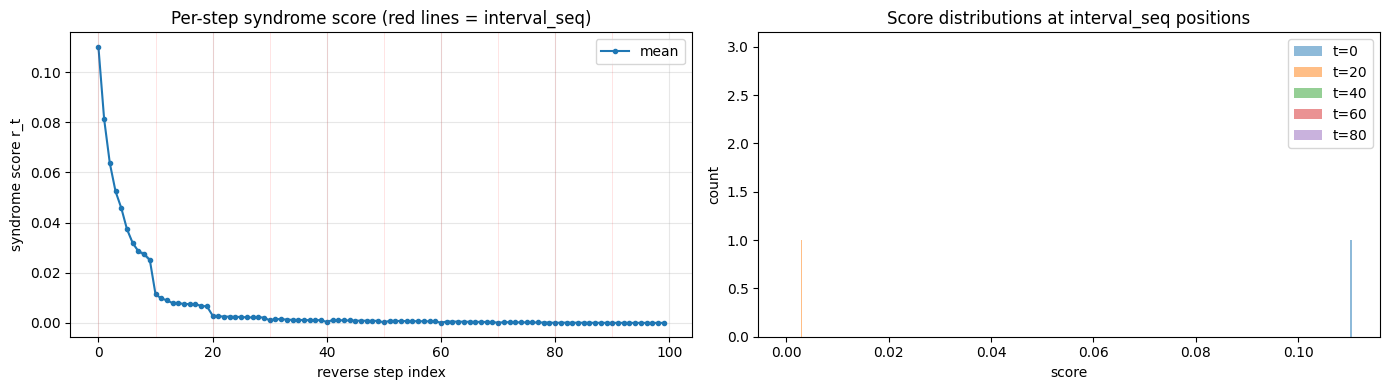

Non-zero steps: 99/100
Max score: 0.110035
✓ Saved ./calibration/pilot_scores_nb.pt


In [9]:
import matplotlib.pyplot as plt

# [T][N_batches] 재구성
T = len(args._pilot_scores[0])
scores_by_t = [[] for _ in range(T)]
for batch_scores in args._pilot_scores:
    for t_idx, s in enumerate(batch_scores):
        scores_by_t[t_idx].append(float(s))

# Score 시각화
score_means = np.array([np.mean(s) if s else 0.0 for s in scores_by_t])
score_stds = np.array([np.std(s) if len(s) > 1 else 0.0 for s in scores_by_t])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(score_means, marker='o', markersize=3, label='mean')
axes[0].fill_between(range(T), score_means - score_stds, score_means + score_stds, alpha=0.3)

# interval_seq 위치 강조
for pos in args.interval_seq:
    axes[0].axvline(pos, color='red', alpha=0.15, linewidth=0.5)
axes[0].set_xlabel('reverse step index')
axes[0].set_ylabel('syndrome score r_t')
axes[0].set_title('Per-step syndrome score (red lines = interval_seq)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Distribution at selected steps
for t_show in list(args.interval_seq)[::2][:5]:
    if scores_by_t[t_show]:
        axes[1].hist(scores_by_t[t_show], bins=15, alpha=0.5, label=f't={t_show}')
axes[1].set_xlabel('score')
axes[1].set_ylabel('count')
axes[1].set_title('Score distributions at interval_seq positions')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Non-zero steps: {int((score_means > 0).sum())}/{T}")
print(f"Max score: {score_means.max():.6f}")

# 저장
torch.save(scores_by_t, './calibration/pilot_scores_nb.pt')
print("✓ Saved ./calibration/pilot_scores_nb.pt")

# 여러 percentile로 Tau 생성

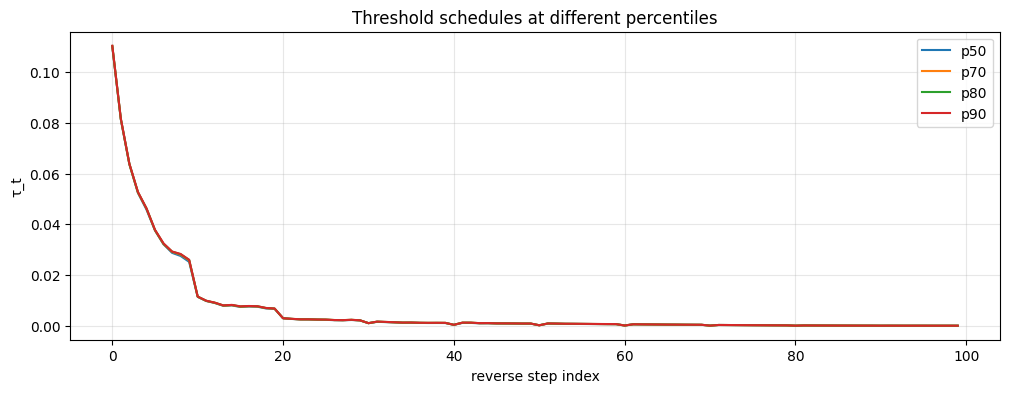

p50: mean=0.006441, max=0.110035, nonzero=99/100
p70: mean=0.006486, max=0.110237, nonzero=99/100
p80: mean=0.006507, max=0.110330, nonzero=99/100
p90: mean=0.006527, max=0.110416, nonzero=99/100

✓ Tau schedules saved


In [10]:
# 각 percentile별 tau
tau_schedules = {}
for pct in [50, 70, 80, 90]:
    tau = calibrate_tau_from_scores(scores_by_t, percentile=pct)
    tau_schedules[pct] = tau
    torch.save(torch.from_numpy(tau), f'./calibration/tau_schedule_p{pct}.pt')

# 시각화
fig, ax = plt.subplots(figsize=(12, 4))
for pct, tau in tau_schedules.items():
    ax.plot(tau, label=f'p{pct}')
ax.set_xlabel('reverse step index')
ax.set_ylabel('τ_t')
ax.set_title('Threshold schedules at different percentiles')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

for pct, tau in tau_schedules.items():
    nonzero = int((tau > 0).sum())
    print(f"p{pct}: mean={tau.mean():.6f}, max={tau.max():.6f}, nonzero={nonzero}/{len(tau)}")

print("\n✓ Tau schedules saved")

# Sanity Run (500 샘플 S-IEC 적용)

In [11]:
# S-IEC 활성화, p80 사용
args.siec_collect_scores = False
args.tau_schedule = tau_schedules[80]
args.image_folder = './error_dec/cifar/image_siec_sanity_nb'
os.makedirs(args.image_folder, exist_ok=True)

torch.cuda.empty_cache()
print(f"GPU mem before: {torch.cuda.memory_allocated()/1e9:.2f} GB")

seed_everything(args.seed)
model.time = 0

print(f"\nStarting S-IEC sanity run...")
start = time.time()
runner.sample_fid(q_unet, total_n_samples=args.num_samples)
elapsed = time.time() - start
print(f"\n✓ Sanity done in {elapsed:.1f}s ({elapsed/60:.1f} min)")

INFO:ddpm.runners.deepcache:starting from image 0


GPU mem before: 0.30 GB

Starting S-IEC sanity run...


Throughput: 6.90 samples/s: 100%|██████████| 5/5 [01:12<00:00, 14.59s/it]
INFO:ddpm.runners.deepcache:Time taken: 72.96535921096802 seconds



✓ Sanity done in 73.0s (1.2 min)


# 이미지 확인

Generated 500 samples


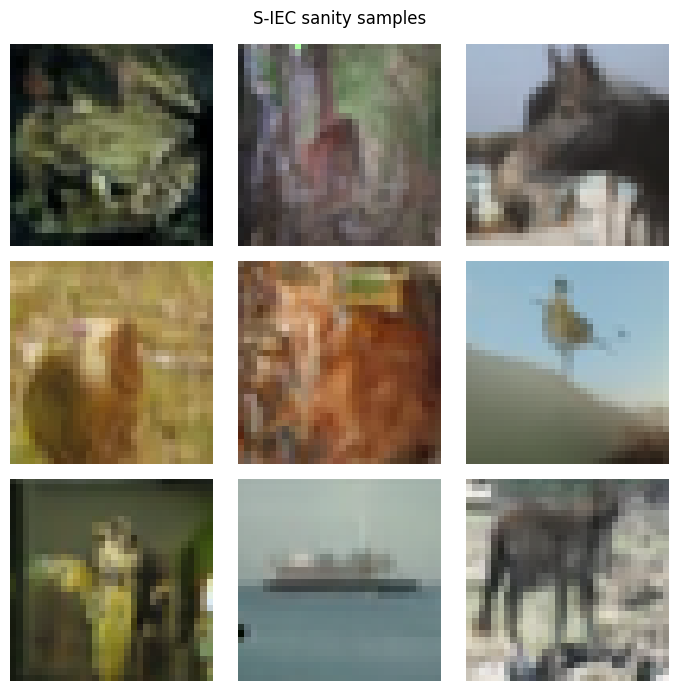


Stats (50 random): mean=128.0, std=42.9, min=0.0, max=255.0
(Expected: mean~100-150, std~50-80, min~0, max~255)


In [12]:
from PIL import Image
import glob, random

files = sorted(glob.glob(os.path.join(args.image_folder, '*.png')))
print(f"Generated {len(files)} samples")

# 3x3 샘플
random.seed(42)
pick = random.sample(files, 9)
fig, axes = plt.subplots(3, 3, figsize=(7, 7))
for ax, f in zip(axes.flatten(), pick):
    ax.imshow(np.array(Image.open(f)))
    ax.axis('off')
plt.suptitle('S-IEC sanity samples')
plt.tight_layout()
plt.show()

# 통계
stats = []
for f in random.sample(files, 50):
    arr = np.array(Image.open(f))
    stats.append((arr.mean(), arr.std(), arr.min(), arr.max()))
stats = np.array(stats)
print(f"\nStats (50 random): mean={stats[:,0].mean():.1f}, std={stats[:,1].mean():.1f}, "
      f"min={stats[:,2].min()}, max={stats[:,3].max()}")
print("(Expected: mean~100-150, std~50-80, min~0, max~255)")

# full run

In [13]:
# 주의: Notebook에서 50000은 1 GPU 기준 ~1시간
# CLI multi-GPU가 훨씬 빠르지만 여기서는 1 GPU 기준

# 옵션 A: 여기서 notebook으로 돌리기 (1 GPU, ~1시간)
# 옵션 B: CLI로 넘기기 (4 GPU, ~15분)

# 아래는 옵션 A (notebook full run)
RUN_FULL_IN_NOTEBOOK = True  # ★ True로 바꾸면 실행

if RUN_FULL_IN_NOTEBOOK:
    args.num_samples = 50000
    args.sample_batch = 500
    args.siec_collect_scores = False
    args.tau_schedule = tau_schedules[80]
    args.image_folder = './error_dec/cifar/image_siec_full_nb'
    os.makedirs(args.image_folder, exist_ok=True)
    
    torch.cuda.empty_cache()
    seed_everything(args.seed)
    model.time = 0
    
    print(f"Starting FULL run with {args.num_samples} samples (1 GPU)...")
    start = time.time()
    runner.sample_fid(q_unet, total_n_samples=args.num_samples)
    elapsed = time.time() - start
    print(f"\n✓ Full run done in {elapsed/60:.1f} min")
else:
    print("""
Full run skipped in notebook.

Run in CLI with 4 GPUs (much faster, ~15-20 min):

  tmux new -s siec_full
  conda activate iec
  cd ~/jowithu/Semantic/IEC
  
  accelerate launch --num_processes 4 mainddpm/ddim_cifar_siec.py \\
      --config ./mainddpm/configs/cifar10.yml \\
      --timesteps 100 --replicate_interval 10 \\
      --weight_bit 8 --act_bit 8 \\
      --num_samples 50000 --sample_batch 500 \\
      --tau_path ./calibration/tau_schedule_p80.pt \\
      --image_folder ./error_dec/cifar/image_siec_full \\
      2>&1 | tee logs/siec_full_p80.log
""")

INFO:ddpm.runners.deepcache:starting from image 0


Starting FULL run with 50000 samples (1 GPU)...


Throughput: 6.23 samples/s: 100%|██████████| 100/100 [2:14:02<00:00, 80.43s/it] 
INFO:ddpm.runners.deepcache:Time taken: 8042.949655294418 seconds



✓ Full run done in 134.0 min


# FID 측정 

In [14]:
import os
import glob

IMAGE_DIR = './error_dec/cifar/image_siec_full_nb'

if os.path.exists(IMAGE_DIR):
    num_imgs = len(glob.glob(f"{IMAGE_DIR}/*.png"))
else:
    num_imgs = 0

print(f"Found {num_imgs:,} images in {IMAGE_DIR}")

if num_imgs >= 50000:
    print("✓ Full run complete, converting to npz...")
    
    from tqdm import tqdm       # ★ 변경: tqdm.notebook → tqdm
    import numpy as np
    from PIL import Image
    
    files = sorted(glob.glob(f"{IMAGE_DIR}/*.png"))
    imgs = []
    for f in tqdm(files, desc="Loading PNGs"):
        arr = np.array(Image.open(f))
        if arr.ndim == 2:
            arr = np.stack([arr]*3, axis=-1)
        imgs.append(arr)
    imgs = np.stack(imgs)
    np.savez('./siec_samples.npz', arr_0=imgs)
    print(f"✓ Saved siec_samples.npz, shape={imgs.shape}")
    
    print("""
Now run FID in CLI (CPU heavy, ~50 min):

  tmux new -s siec_fid
  conda activate iec
  cd ~/jowithu/Semantic/IEC
  
  CUDA_VISIBLE_DEVICES=-1 python evaluator_FID.py \\
      cifar10_reference.npz siec_samples.npz \\
      2>&1 | tee logs/siec_fid.log
""")
else:
    print(f"⏳ Not enough images ({num_imgs:,} / 50,000)")
    print(f"   Progress: {num_imgs/50000*100:.1f}%")
    if num_imgs == 0:
        if not os.path.exists(IMAGE_DIR):
            print(f"   Folder does not exist yet: {IMAGE_DIR}")
        print(f"   Run full run first!")
    else:
        print(f"   Full run still in progress. Wait and re-run this cell later.")

Found 50,000 images in ./error_dec/cifar/image_siec_full_nb
✓ Full run complete, converting to npz...


Loading PNGs: 100%|██████████| 50000/50000 [00:04<00:00, 11628.21it/s]


✓ Saved siec_samples.npz, shape=(50000, 32, 32, 3)

Now run FID in CLI (CPU heavy, ~50 min):

  tmux new -s siec_fid
  conda activate iec
  cd ~/jowithu/Semantic/IEC
  
  CUDA_VISIBLE_DEVICES=-1 python evaluator_FID.py \
      cifar10_reference.npz siec_samples.npz \
      2>&1 | tee logs/siec_fid.log



# 이미지 확인 (full run)

./error_dec/cifar/image_siec_full_nb: 50,000 images
./error_dec/cifar/image_siec_pilot_nb: 500 images
./error_dec/cifar/image_siec_sanity_nb: 500 images
Total full-run images: 50,000


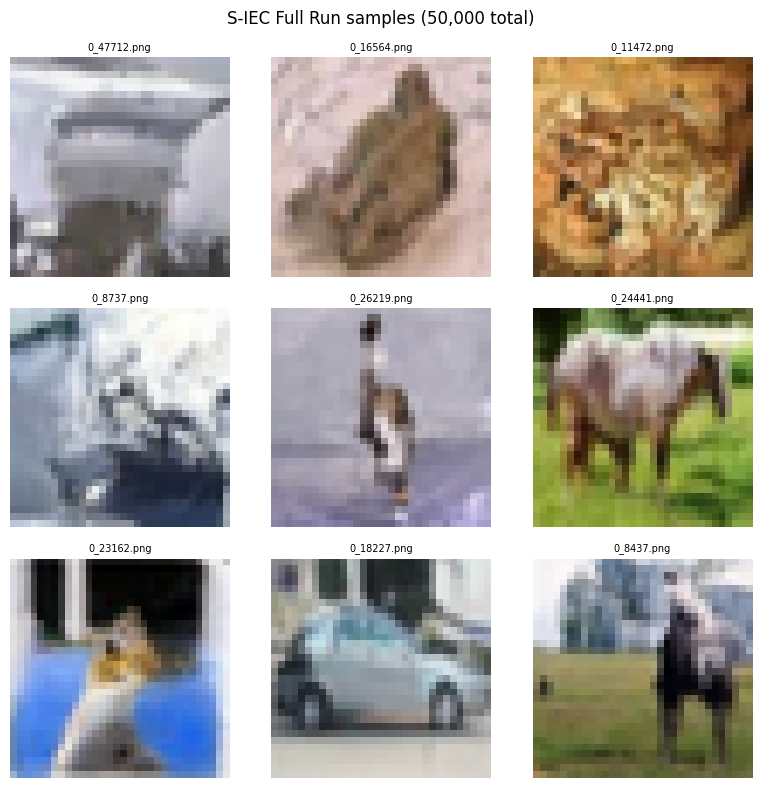

In [15]:
import os
import glob
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

FULL_DIR = './error_dec/cifar/image_siec_full_nb'   # notebook full run 결과
PILOT_DIR = './error_dec/cifar/image_siec_pilot_nb' # pilot 결과 (비교용)
SANITY_DIR = './error_dec/cifar/image_siec_sanity_nb' # sanity 결과 (비교용)

# 개수 확인
for d in [FULL_DIR, PILOT_DIR, SANITY_DIR]:
    if os.path.exists(d):
        cnt = len(os.listdir(d))
        print(f"{d}: {cnt:,} images")
    else:
        print(f"{d}: (not found)")
        
# Full run 결과에서 9장 무작위 추출
files = sorted(os.listdir(FULL_DIR))
print(f"Total full-run images: {len(files):,}")

random.seed(42)
pick = random.sample(files, 9)

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for ax, f in zip(axes.flatten(), pick):
    img = np.array(Image.open(os.path.join(FULL_DIR, f)))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f, fontsize=7)

plt.suptitle(f'S-IEC Full Run samples ({len(files):,} total)', fontsize=12)
plt.tight_layout()
plt.show()

Sanity: 500, Full: 50,000


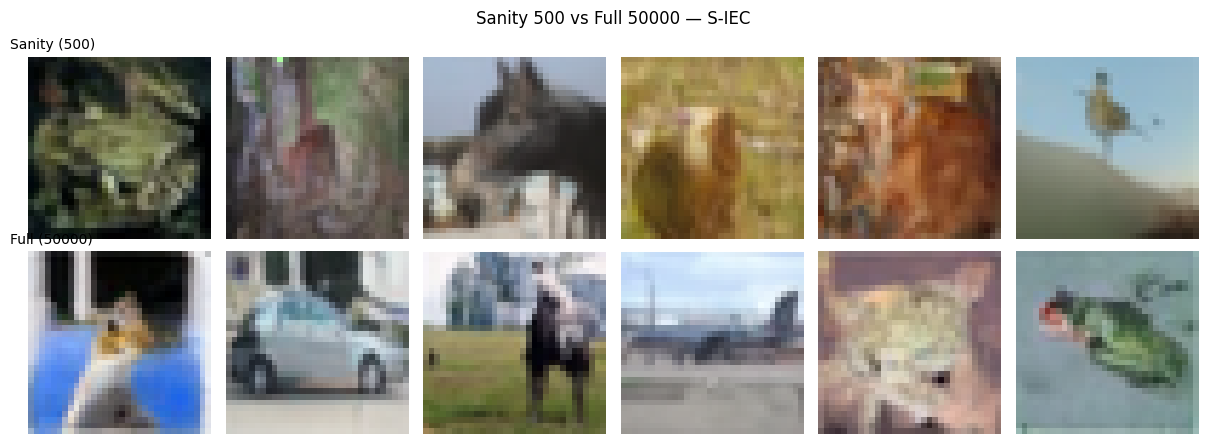

In [16]:
# Sanity (500) vs Full (50000) 나란히 비교
random.seed(42)

sanity_files = sorted(os.listdir(SANITY_DIR)) if os.path.exists(SANITY_DIR) else []
full_files = sorted(os.listdir(FULL_DIR))

print(f"Sanity: {len(sanity_files):,}, Full: {len(full_files):,}")

# 각각 6장씩
n_show = 6
if sanity_files:
    pick_sanity = random.sample(sanity_files, n_show)
pick_full = random.sample(full_files, n_show)

fig, axes = plt.subplots(2, n_show, figsize=(n_show * 2, 4.5))

for col, f in enumerate(pick_sanity if sanity_files else [None]*n_show):
    if f:
        img = np.array(Image.open(os.path.join(SANITY_DIR, f)))
        axes[0, col].imshow(img)
    axes[0, col].axis('off')
    if col == 0:
        axes[0, col].set_title('Sanity (500)', fontsize=10, loc='left', x=-0.1)

for col, f in enumerate(pick_full):
    img = np.array(Image.open(os.path.join(FULL_DIR, f)))
    axes[1, col].imshow(img)
    axes[1, col].axis('off')
    if col == 0:
        axes[1, col].set_title('Full (50000)', fontsize=10, loc='left', x=-0.1)

plt.suptitle('Sanity 500 vs Full 50000 — S-IEC', fontsize=12)
plt.tight_layout()
plt.show()

# 원본 이미지 와의 비교

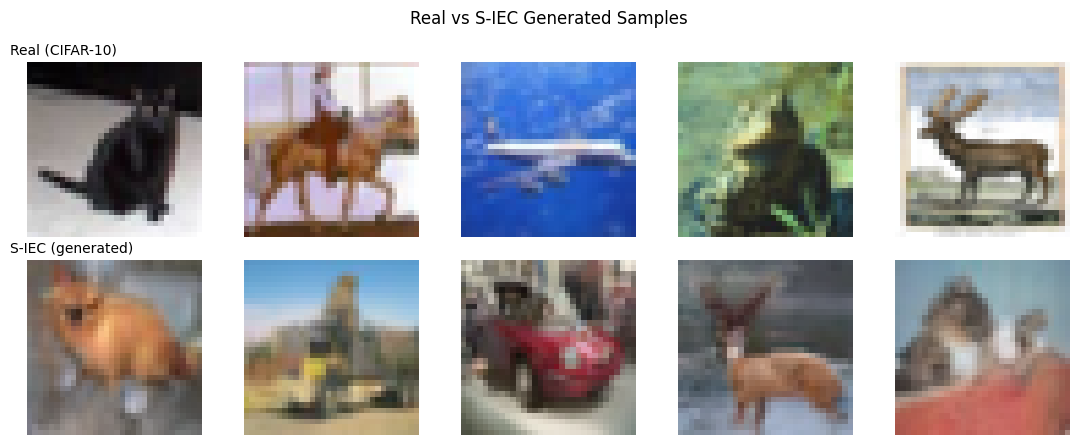

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import os, random
from PIL import Image

# 원본
data = np.load('./cifar10_reference.npz')
originals = data['arr_0']

# S-IEC 생성물
SIEC_DIR = './error_dec/cifar/image_siec_full_nb'
siec_files = sorted(os.listdir(SIEC_DIR))

# 각 5장씩
random.seed(0)
orig_idx = random.sample(range(50000), 5)
siec_idx = random.sample(range(len(siec_files)), 5)

fig, axes = plt.subplots(2, 5, figsize=(11, 4.5))
for col, idx in enumerate(orig_idx):
    axes[0, col].imshow(originals[idx])
    axes[0, col].axis('off')
axes[0, 0].set_title('Real (CIFAR-10)', loc='left', x=-0.1, fontsize=10)

for col, idx in enumerate(siec_idx):
    axes[1, col].imshow(np.array(Image.open(os.path.join(SIEC_DIR, siec_files[idx]))))
    axes[1, col].axis('off')
axes[1, 0].set_title('S-IEC (generated)', loc='left', x=-0.1, fontsize=10)

plt.suptitle('Real vs S-IEC Generated Samples', fontsize=12)
plt.tight_layout()
plt.show()

# Step 1: Path Error / Martingale Deviation 측정 ⭐⭐⭐

In [18]:
# ========== Path Error & Martingale Deviation 측정 ==========
import torch
import numpy as np
from mainddpm.ddpm.functions.deepcache_denoising import adaptive_generalized_steps_trace

# 같은 initial noise 준비 (공정 비교)
n_samples = 64   # 작게 (측정용)
torch.manual_seed(42)
x_init = torch.randn(n_samples, 3, 32, 32, device='cuda')

timesteps = args.timesteps
seq = (np.linspace(0, np.sqrt(runner.num_timesteps * 0.8), timesteps) ** 2)
seq = [int(s) for s in list(seq)]

print(f"Running trace with {n_samples} samples, {timesteps} steps...")

# --- IEC trace ---
print("\n[IEC trace]")
seed_everything(args.seed)
q_unet.model.time = 0
xs_iec, x0_preds_iec, trace_iec = adaptive_generalized_steps_trace(
    x_init.clone(), seq, q_unet, runner.betas,
    timesteps=timesteps,
    interval_seq=args.interval_seq,
    branch=args.branch,
    eta=0.0,
    quant=args.ptq,
    mode='iec',
)
print(f"  Total NFE: {sum(trace_iec['nfe_per_step'])}")
print(f"  Syndrome mean: {np.mean(trace_iec['syndrome_per_step']):.6f}")
print(f"  Non-zero syndrome steps: {sum(1 for s in trace_iec['syndrome_per_step'] if s > 0)}")

# --- S-IEC trace ---
print("\n[S-IEC trace]")
seed_everything(args.seed)
q_unet.model.time = 0
xs_siec, x0_preds_siec, trace_siec = adaptive_generalized_steps_trace(
    x_init.clone(), seq, q_unet, runner.betas,
    timesteps=timesteps,
    interval_seq=args.interval_seq,
    branch=args.branch,
    eta=0.0,
    quant=args.ptq,
    mode='siec',
    c_siec=1.0,
    siec_always_correct=False,
    siec_max_rounds=1,
)
print(f"  Total NFE: {sum(trace_siec['nfe_per_step'])}")
print(f"  Syndrome mean: {np.mean(trace_siec['syndrome_per_step']):.6f}")
print(f"  Triggered steps: {sum(trace_siec['triggered_per_step'])}/{len(trace_siec['triggered_per_step'])}")

Running trace with 64 samples, 100 steps...

[IEC trace]
  Total NFE: 298
  Syndrome mean: 0.006521
  Non-zero syndrome steps: 99

[S-IEC trace]
  Total NFE: 199
  Syndrome mean: 0.006442
  Triggered steps: 0/100


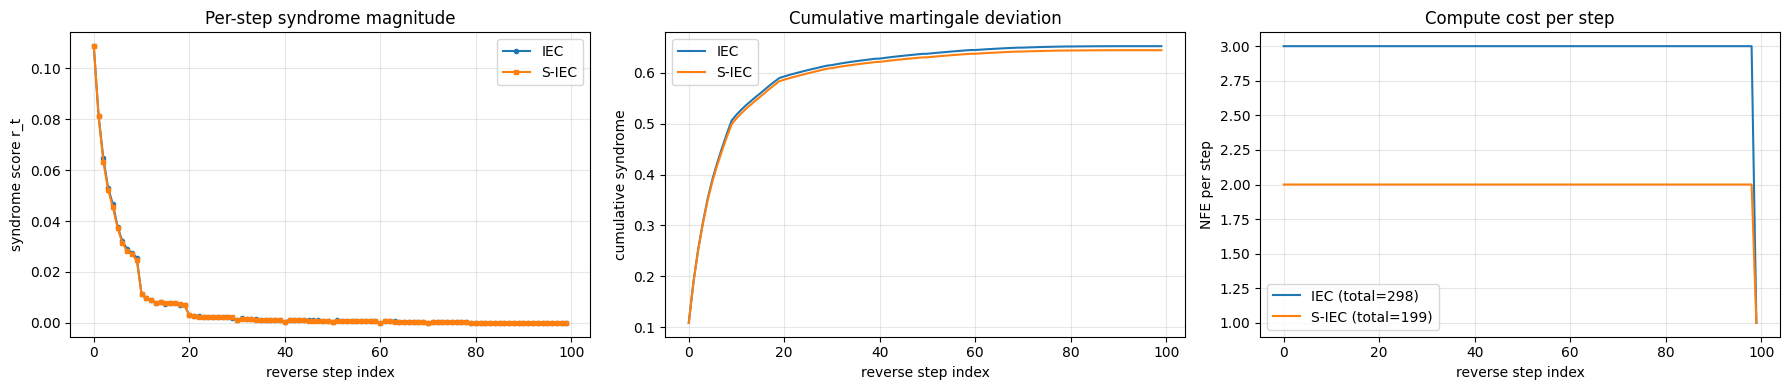


Metric                                  IEC        S-IEC
------------------------------------------------------------
Total NFE                               298          199
Mean syndrome                      0.006521     0.006442
Max syndrome                       0.108757     0.108757
Cumulative syndrome                0.652119     0.644200
Triggered steps (S-IEC)                   -            0


In [19]:
import matplotlib.pyplot as plt

# 1. Per-step syndrome 비교
syn_iec = np.array(trace_iec['syndrome_per_step'])
syn_siec = np.array(trace_siec['syndrome_per_step'])

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Plot 1: syndrome per step
axes[0].plot(syn_iec, label='IEC', marker='o', markersize=3)
axes[0].plot(syn_siec, label='S-IEC', marker='s', markersize=3)
axes[0].set_xlabel('reverse step index')
axes[0].set_ylabel('syndrome score r_t')
axes[0].set_title('Per-step syndrome magnitude')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: cumulative syndrome (martingale deviation)
cum_iec = np.cumsum(syn_iec)
cum_siec = np.cumsum(syn_siec)
axes[1].plot(cum_iec, label='IEC')
axes[1].plot(cum_siec, label='S-IEC')
axes[1].set_xlabel('reverse step index')
axes[1].set_ylabel('cumulative syndrome')
axes[1].set_title('Cumulative martingale deviation')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot 3: NFE per step
nfe_iec = np.array(trace_iec['nfe_per_step'])
nfe_siec = np.array(trace_siec['nfe_per_step'])
axes[2].plot(nfe_iec, label=f'IEC (total={nfe_iec.sum()})')
axes[2].plot(nfe_siec, label=f'S-IEC (total={nfe_siec.sum()})')
axes[2].set_xlabel('reverse step index')
axes[2].set_ylabel('NFE per step')
axes[2].set_title('Compute cost per step')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./experiments/path_error_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 결과 요약
print(f"\n{'='*60}")
print(f"{'Metric':<30} {'IEC':>12} {'S-IEC':>12}")
print(f"{'-'*60}")
print(f"{'Total NFE':<30} {nfe_iec.sum():>12} {nfe_siec.sum():>12}")
print(f"{'Mean syndrome':<30} {syn_iec.mean():>12.6f} {syn_siec.mean():>12.6f}")
print(f"{'Max syndrome':<30} {syn_iec.max():>12.6f} {syn_siec.max():>12.6f}")
print(f"{'Cumulative syndrome':<30} {cum_iec[-1]:>12.6f} {cum_siec[-1]:>12.6f}")
print(f"{'Triggered steps (S-IEC)':<30} {'-':>12} {sum(trace_siec['triggered_per_step']):>12}")

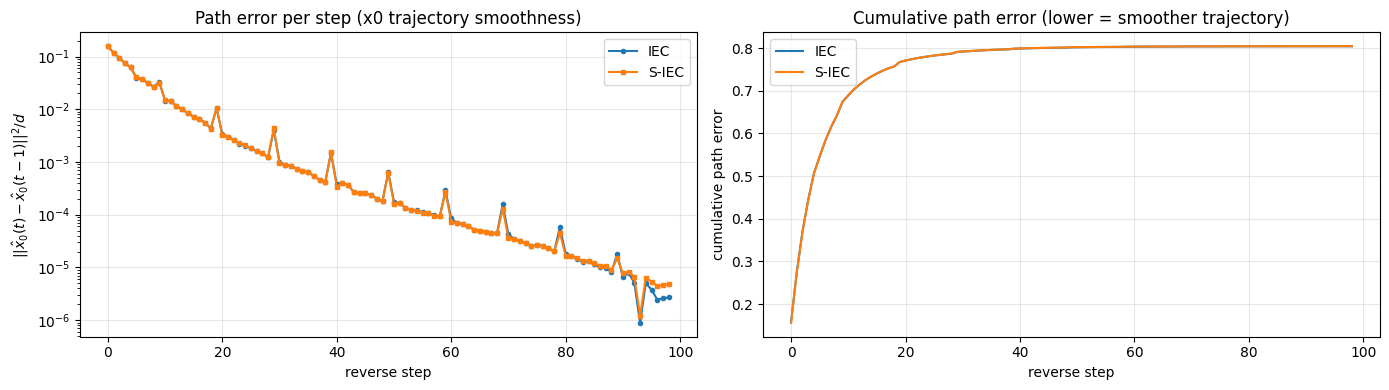


PATH ERROR COMPARISON
------------------------------------------------------------
Total path error - IEC:   0.8042
Total path error - S-IEC: 0.8044
Relative: S-IEC is -0.0% lower


In [20]:
# Path error: ||x0(t) - x0(t-1)||² 각 step
def compute_path_error(trajectory):
    """trajectory: list of (B, C, H, W) tensors"""
    errors = []
    d = trajectory[0][0].numel()
    for i in range(1, len(trajectory)):
        diff = trajectory[i] - trajectory[i-1]
        err = (diff ** 2).flatten(1).sum(dim=1) / d   # (B,)
        errors.append(err.mean().item())
    return np.array(errors)

path_err_iec = compute_path_error(trace_iec['x0_trajectory'])
path_err_siec = compute_path_error(trace_siec['x0_trajectory'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(path_err_iec, label='IEC', marker='o', markersize=3)
axes[0].plot(path_err_siec, label='S-IEC', marker='s', markersize=3)
axes[0].set_xlabel('reverse step')
axes[0].set_ylabel(r'$||\hat{x}_0(t) - \hat{x}_0(t-1)||^2 / d$')
axes[0].set_title('Path error per step (x0 trajectory smoothness)')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(np.cumsum(path_err_iec), label='IEC')
axes[1].plot(np.cumsum(path_err_siec), label='S-IEC')
axes[1].set_xlabel('reverse step')
axes[1].set_ylabel('cumulative path error')
axes[1].set_title('Cumulative path error (lower = smoother trajectory)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./experiments/path_error.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*60}")
print(f"PATH ERROR COMPARISON")
print(f"{'-'*60}")
print(f"Total path error - IEC:   {path_err_iec.sum():.4f}")
print(f"Total path error - S-IEC: {path_err_siec.sum():.4f}")
print(f"Relative: S-IEC is {(1 - path_err_siec.sum()/path_err_iec.sum())*100:.1f}% lower")

In [21]:
print(f"IEC triggered: {sum(trace_iec['triggered_per_step'])}/{len(trace_iec['triggered_per_step'])}")
print(f"S-IEC triggered: {sum(trace_siec['triggered_per_step'])}/{len(trace_siec['triggered_per_step'])}")

# S-IEC triggered가 언제인지
for i, trig in enumerate(trace_siec['triggered_per_step']):
    if trig:
        print(f"  S-IEC triggered at step {i}, syndrome={trace_siec['syndrome_per_step'][i]:.6f}")

IEC triggered: 99/100
S-IEC triggered: 0/100


In [22]:
# S-IEC always correct
seed_everything(args.seed)
q_unet.model.time = 0
xs_always, x0_always, trace_always = adaptive_generalized_steps_trace(
    x_init.clone(), seq, q_unet, runner.betas,
    timesteps=timesteps,
    interval_seq=args.interval_seq,
    branch=args.branch,
    eta=0.0,
    quant=args.ptq,
    mode='siec',
    c_siec=1.0,
    tau_schedule=None,
    siec_always_correct=True,   # ★ 항상 correction
)

path_err_always = compute_path_error(trace_always['x0_trajectory'])

print(f"\n{'='*60}")
print(f"{'Metric':<30} {'IEC':>10} {'S-IEC(p80)':>12} {'S-IEC(always)':>15}")
print('-' * 70)
print(f"{'Path error total':<30} {path_err_iec.sum():>10.4f} {path_err_siec.sum():>12.4f} {path_err_always.sum():>15.4f}")
print(f"{'Syndrome mean':<30} {np.mean(trace_iec['syndrome_per_step']):>10.6f} "
      f"{np.mean(trace_siec['syndrome_per_step']):>12.6f} "
      f"{np.mean(trace_always['syndrome_per_step']):>15.6f}")
print(f"{'NFE total':<30} {sum(trace_iec['nfe_per_step']):>10} "
      f"{sum(trace_siec['nfe_per_step']):>12} "
      f"{sum(trace_always['nfe_per_step']):>15}")
print(f"{'Triggered':<30} {'-':>10} "
      f"{sum(trace_siec['triggered_per_step']):>12} "
      f"{sum(trace_always['triggered_per_step']):>15}")


Metric                                IEC   S-IEC(p80)   S-IEC(always)
----------------------------------------------------------------------
Path error total                   0.8042       0.8044          0.8055
Syndrome mean                    0.006521     0.006442        0.006536
NFE total                             298          199             199
Triggered                               -            0              99


In [23]:
for c in [0.3, 0.5, 1.0, 1.5, 2.0]:
    seed_everything(args.seed)
    q_unet.model.time = 0
    xs, x0p, trace = adaptive_generalized_steps_trace(
        x_init.clone(), seq, q_unet, runner.betas,
        timesteps=timesteps,
        interval_seq=args.interval_seq,
        branch=args.branch,
        eta=0.0,
        quant=args.ptq,
        mode='siec',
        c_siec=c,
        tau_schedule=None,
        siec_always_correct=True,
    )
    path_err = compute_path_error(trace['x0_trajectory'])
    print(f"c={c}: path_error_total={path_err.sum():.4f}, "
          f"syndrome_mean={np.mean(trace['syndrome_per_step']):.6f}")

c=0.3: path_error_total=0.8056, syndrome_mean=0.006497
c=0.5: path_error_total=0.8050, syndrome_mean=0.006515
c=1.0: path_error_total=0.8055, syndrome_mean=0.006536
c=1.5: path_error_total=0.8068, syndrome_mean=0.006555
c=2.0: path_error_total=0.8056, syndrome_mean=0.006568


# 다양한 c 로 측정

In [24]:
# ========== c_siec 스위프 (2000 samples each) ==========

# GPU가 여유 있으면 한 번에, 없으면 순차적으로
c_candidates = [0.3, 0.5, 1.0, 1.5, 2.0]

# 먼저 짧은 샘플로 각 c에 대해 path error + quick sampling
results = {}

for c in c_candidates:
    print(f"\n{'='*60}")
    print(f"Testing c_siec = {c}")
    print('='*60)
    
    # Path error 측정 (64 samples, 빠름)
    torch.manual_seed(42)
    x_init = torch.randn(64, 3, 32, 32, device='cuda')
    
    seed_everything(args.seed)
    q_unet.model.time = 0
    _, _, trace = adaptive_generalized_steps_trace(
        x_init, seq, q_unet, runner.betas,
        timesteps=timesteps,
        interval_seq=args.interval_seq,
        branch=args.branch,
        eta=0.0,
        quant=args.ptq,
        mode='siec',
        c_siec=c,
        tau_schedule=tau_schedules[80],
    )
    
    path_err = compute_path_error(trace['x0_trajectory'])
    syn = np.array(trace['syndrome_per_step'])
    nfe = np.array(trace['nfe_per_step'])
    
    results[c] = {
        'path_error_total': path_err.sum(),
        'syndrome_mean': syn.mean(),
        'nfe_total': nfe.sum(),
        'triggered_count': sum(trace['triggered_per_step']),
    }
    
    print(f"  path error total:  {path_err.sum():.4f}")
    print(f"  syndrome mean:     {syn.mean():.6f}")
    print(f"  NFE total:         {nfe.sum()}")
    print(f"  triggered steps:   {sum(trace['triggered_per_step'])}")

# 요약 테이블
print(f"\n{'='*60}")
print(f"{'c_siec':<8} {'PathErr':<10} {'MeanSyn':<12} {'NFE':<6} {'Trig':<6}")
print('-' * 60)
for c in c_candidates:
    r = results[c]
    print(f"{c:<8} {r['path_error_total']:<10.4f} {r['syndrome_mean']:<12.6f} {r['nfe_total']:<6} {r['triggered_count']:<6}")


Testing c_siec = 0.3
  path error total:  0.8052
  syndrome mean:     0.006462
  NFE total:         199
  triggered steps:   68

Testing c_siec = 0.5
  path error total:  0.8054
  syndrome mean:     0.006468
  NFE total:         199
  triggered steps:   67

Testing c_siec = 1.0
  path error total:  0.8061
  syndrome mean:     0.006483
  NFE total:         199
  triggered steps:   67

Testing c_siec = 1.5
  path error total:  0.8066
  syndrome mean:     0.006491
  NFE total:         199
  triggered steps:   67

Testing c_siec = 2.0
  path error total:  0.8068
  syndrome mean:     0.006497
  NFE total:         199
  triggered steps:   65

c_siec   PathErr    MeanSyn      NFE    Trig  
------------------------------------------------------------
0.3      0.8052     0.006462     199    68    
0.5      0.8054     0.006468     199    67    
1.0      0.8061     0.006483     199    67    
1.5      0.8066     0.006491     199    67    
2.0      0.8068     0.006497     199    65    


# 코드 구현 확인

In [25]:
from siec_core.correction import apply_consensus_correction
import torch

x0_t = torch.randn(4, 3, 32, 32)
x0_look = x0_t + torch.randn_like(x0_t) * 0.1  # 일부러 차이 만듦
syndrome = x0_t - x0_look

for c in [0.3, 1.0, 2.0]:
    gamma = c * 0.5 / (0.5 + 0.5)   # 간단히
    gamma = compute_gamma(0.5, 0.5, c=c)
    x0_corrected = apply_consensus_correction(x0_t, syndrome, gamma)
    diff = (x0_t - x0_corrected).abs().mean().item()
    print(f"c={c}, gamma={gamma:.4f}, avg |Δx0|={diff:.6f}")

c=0.3, gamma=0.1304, avg |Δx0|=0.010300
c=1.0, gamma=0.3333, avg |Δx0|=0.026323
c=2.0, gamma=0.5000, avg |Δx0|=0.039485


In [26]:
# c=1.0, tau_p80, triggered 3번이었던 동일 조건
seed_everything(args.seed)
q_unet.model.time = 0
xs_siec_fixed, x0_preds_siec_fixed, trace_siec_fixed = adaptive_generalized_steps_trace(
    x_init.clone(), seq, q_unet, runner.betas,
    timesteps=timesteps,
    interval_seq=args.interval_seq,
    branch=args.branch,
    eta=0.0, quant=args.ptq,
    mode='siec',
    c_siec=1.0,
    siec_always_correct=False,
)

print(f"Triggered: {sum(trace_siec_fixed['triggered_per_step'])}")

# 수정 전후 비교
img_before = xs_siec[-1]  # 아까 돌린 버그 버전
img_after = xs_siec_fixed[-1]
diff = (img_before - img_after).pow(2).mean().item()
print(f"MSE (before vs after fix): {diff:.6f}")
# 0이면 correction이 안 일어난 경우 (trigger 상황 같음)
# 0이 아니면 correction 강도가 달라진 것 ← 정상

# x_t 공간에서의 변화량
delta_iec_fixed = (xs_iec[-1] - xs_siec_fixed[-1]).pow(2).mean().item()
delta_iec_old = (xs_iec[-1] - xs_siec[-1]).pow(2).mean().item()
print(f"\n|S-IEC(fixed) - IEC|²: {delta_iec_fixed:.6f}")
print(f"|S-IEC(old)   - IEC|²: {delta_iec_old:.6f}")
# fixed가 더 크면 correction이 더 강해진 것 (toy와 일치하는 방향)

Triggered: 0
MSE (before vs after fix): 0.000000

|S-IEC(fixed) - IEC|²: 0.000320
|S-IEC(old)   - IEC|²: 0.000320


In [27]:
# always_correct로 fixed 버전과 이전 버전 비교
# (이전 버전 재현을 위해 git stash나 수동 rollback 필요하므로 대안)

# 대신: path error와 x_t space 차이 확인
path_err_fixed = compute_path_error(trace_siec_fixed['x0_trajectory'])
path_err_old = compute_path_error(trace_siec['x0_trajectory'])
path_err_iec = compute_path_error(trace_iec['x0_trajectory'])

print(f"Path error total:")
print(f"  IEC:                {path_err_iec.sum():.4f}")
print(f"  S-IEC (old, buggy): {path_err_old.sum():.4f}")
print(f"  S-IEC (fixed):      {path_err_fixed.sum():.4f}")

Path error total:
  IEC:                0.8042
  S-IEC (old, buggy): 0.8044
  S-IEC (fixed):      0.8044


In [28]:
# Always correct로 fix 효과 확인
seed_everything(args.seed)
q_unet.model.time = 0
xs_always_fixed, _, trace_always_fixed = adaptive_generalized_steps_trace(
    x_init.clone(), seq, q_unet, runner.betas,
    timesteps=timesteps,
    interval_seq=args.interval_seq,
    branch=args.branch,
    eta=0.0, quant=args.ptq,
    mode='siec',
    c_siec=1.0,
    tau_schedule=None,
    siec_always_correct=True,   # ★ 매번 correction
)

print(f"Triggered: {sum(trace_always_fixed['triggered_per_step'])}")  # 10이어야 함

# Fix 전 버전과 비교하려면, git이나 backup 파일로 restore 후 돌려야 함
# 대신: IEC와 비교로 correction이 진짜 '제대로 된 방향'으로 가는지 확인
path_err_always = compute_path_error(trace_always_fixed['x0_trajectory'])
print(f"Path error total:")
print(f"  IEC:              {path_err_iec.sum():.4f}")
print(f"  S-IEC (always fixed): {path_err_always.sum():.4f}")

# 최종 x_t 공간 차이
delta = (xs_iec[-1] - xs_always_fixed[-1]).pow(2).mean().item()
print(f"\n|S-IEC(always) - IEC|²: {delta:.6f}")
# 0.000286보다 커야 정상 (correction이 더 강하게 일어남)

Triggered: 99
Path error total:
  IEC:              0.8042
  S-IEC (always fixed): 0.8055

|S-IEC(always) - IEC|²: 0.002946


In [29]:
import torch

# 저장된 tau schedule 파일에서 직접 로드
tau_p80 = torch.load('./calibration/tau_schedule_p80.pt')
print(f"tau_p80 shape: {tau_p80.shape}")
print(f"tau_p80[0]: {tau_p80[0]:.6f}")
print(f"tau_p80 max: {tau_p80.max():.6f}")

# Step 0만 trigger되도록 낮추기
tau_custom = tau_p80.clone()
tau_custom[0] = tau_custom[0] * 0.9  # 0.1103 → 0.09927
print(f"\nCustom tau:")
print(f"  tau_custom[0]: {tau_custom[0]:.6f}  (원래 0.110330의 90%)")
print(f"  예상: syn ~0.1088 > tau ~0.0993 → step 0 TRIGGER")
print(f"  나머지 step들: 그대로 (tau가 syn과 거의 같아서 거의 trigger 안 됨)")

torch.save(tau_custom, './calibration/tau_step0_trigger.pt')
print(f"\n✓ Saved to ./calibration/tau_step0_trigger.pt")

tau_p80 shape: torch.Size([100])
tau_p80[0]: 0.110330
tau_p80 max: 0.110330

Custom tau:
  tau_custom[0]: 0.099297  (원래 0.110330의 90%)
  예상: syn ~0.1088 > tau ~0.0993 → step 0 TRIGGER
  나머지 step들: 그대로 (tau가 syn과 거의 같아서 거의 trigger 안 됨)

✓ Saved to ./calibration/tau_step0_trigger.pt


In [30]:
# 이 tau로 trace
seed_everything(args.seed)
q_unet.model.time = 0
xs_custom, _, trace_custom = adaptive_generalized_steps_trace(
    x_init.clone(), seq, q_unet, runner.betas,
    timesteps=timesteps,
    interval_seq=args.interval_seq,
    branch=args.branch,
    eta=0.0, quant=args.ptq,
    mode='siec',
    c_siec=1.0,
    tau_schedule=tau_custom,
    siec_always_correct=False,
)

# Trigger 확인
triggered_count = sum(trace_custom['triggered_per_step'])
triggered_steps = [i for i, t in enumerate(trace_custom['triggered_per_step']) if t]
print(f"Triggered: {triggered_count}")
print(f"Triggered steps: {triggered_steps}")

# IEC와 차이
delta_custom = (xs_iec[-1] - xs_custom[-1]).pow(2).mean().item()
print(f"\n|S-IEC(step0) - IEC|²: {delta_custom:.6f}")

# Path error
path_err_custom = compute_path_error(trace_custom['x0_trajectory'])
print(f"\nPath error total:")
print(f"  IEC:                  {path_err_iec.sum():.4f}")
print(f"  S-IEC (always):       {path_err_always.sum():.4f}  (prev)")
print(f"  S-IEC (step0 only):   {path_err_custom.sum():.4f}")

Triggered: 73
Triggered steps: [0, 2, 11, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 61, 62, 63, 64, 65, 66, 67, 68, 69, 71, 72, 73, 74, 75, 76, 77, 78, 79, 81, 82, 83, 84, 85, 86]

|S-IEC(step0) - IEC|²: 0.001116

Path error total:
  IEC:                  0.8042
  S-IEC (always):       0.8055  (prev)
  S-IEC (step0 only):   0.8058
